# Тест 4 — зависит ли избыток от шумовой нагрузки детектора

## Зачем это

Ню-классификатор — нейросеть, которая по набору сработавших модулей решает,
похоже ли событие на нейтрино. На экспериментальных данных она принимает примерно
**втрое больше** событий, чем предсказывает симуляция атмосферных мюонов. Это и
называется здесь избытком.

Объяснений осталось два, и для статьи они означают разное:

* **(a) дефицит потока** — генератор недопроизводит какие-то конфигурации мюонов.
  Отклик детектора при этом верен, симуляция нейтрино не затронута, и измеренная
  на ней эффективность переносится на реальные данные;
* **(b) ошибка отклика** — реальные события труднее реконструируются, чем
  симулированные. Тогда тот же механизм портил бы и нейтрино, и эффективность
  **не** переносится.

Этот ноутбук проверяет одну конкретную версию (b): что виноват шум воды.

## Идея теста

Биолюминесценция в Байкале сильно меняется от рана к рану и по сезонам: 29 чистых
ранов охватывают **пятикратный** диапазон по скорости счёта, от 28 до 134 Гц. Эта
вариация существует только в данных — под неё не подгонялся ни один параметр
симуляции, поэтому подделать корреляцию с ней невозможно.

Если избыток гонит шум, то в шумных ранах он должен быть **больше**, и притом
сильнее в трудном хвосте, чем в основной массе событий.

## Термины

Ниже всё, что понадобится. Ноутбук ничего не вычисляет: он читает готовые файлы,
которые произвёл `stages/10_run_noise.py`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

HERE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(HERE / "src"))
import present

present.glossary(["muatm", "exp", "скор ξ", "сигнальный хит", "отбор качества",
                  "избыток", "полоса", "ран", "кластер"])

         muatm  —  симулированные атмосферные мюоны — фон, который мы умеем считать
           exp  —  экспериментальные данные Байкальского телескопа
        скор ξ  —  выход классификатора от 0 до 1; чем выше, тем больше событие похоже на
                   нейтрино по мнению сети
сигнальный хит  —  срабатывание модуля, которому отдельная сеть sig-noise приписала вероятность
                   быть сигналом (а не шумом воды) выше 0.8
отбор качества  —  не меньше восьми сигнальных хитов не менее чем на трёх струнах (в коде это
                   условие называется h8s3, n_sn_hits ≥ 8 и n_sn_strings ≥ 3). Применяется к
                   обеим выборкам одинаково, иначе сравнивать было бы нечего
       избыток  —  во сколько раз доля экспериментальных событий в данной области скора больше
                   такой же доли у симулированных мюонов. Единица означала бы согласие
        полоса  —  интервал скора, например 0.8–0.9
           ран  —  сеанс набора данных одним кластером, от нес

In [2]:
DATA = HERE / "data"
runs = pd.read_parquet(DATA / "10_run_noise.parquet")
reference = pd.read_parquet(DATA / "10_mc_reference.parquet")
partial = pd.read_parquet(DATA / "10_run_noise_partial.parquet")
runs["quality_frac"] = runs.n_quality / runs.n_events_total

BLUE, ORANGE, TEAL, INK, MUTED, SURFACE = (
    "#2a78d6", "#eb6834", "#1baf7a", "#0b0b0b", "#52514e", "#fcfcfb")
print(f"{len(runs)} ранов, {runs.n_quality.sum():,} событий после отбора качества")

29 ранов, 3,353,716 событий после отбора качества


## Шаг 1. С чем сравниваем — эталон по симуляции

Чтобы сказать «в эксперименте событий больше, чем ожидалось», нужно сначала
измерить, чего ожидать. Берём все симулированные атмосферные мюоны, прошедшие
отбор качества, и смотрим, какая их доля попадает в каждую полосу скора.

Эта доля — знаменатель избытка. Она одна и та же для всех ранов: симуляция не
знает, какой ран мы рассматриваем.

In [3]:
present.show(
    reference,
    {"lo": "полоса от", "hi": "полоса до",
     "mc_events": "МК-событий в полосе",
     "mc_quality": "всего МК-событий после отбора качества",
     "mc_share": "доля в полосе = столбец 3 / столбец 4"},
    rows="одна полоса скора",
    source=present.artefact_note(DATA / "10_mc_reference.parquet"),
    note="«Всего МК-событий» одинаково во всех строках — это общий знаменатель, "
         "23.17 млн симулированных мюонов, прошедших отбор качества. Доля в "
         "полосе мала, потому что классификатор почти все мюоны отвергает: в "
         "верхнюю полосу попадает 1.4 события из десяти тысяч.",
    decimals=6)

Строка — одна полоса скора.
«Всего МК-событий» одинаково во всех строках — это общий знаменатель, 23.17 млн симулированных
мюонов, прошедших отбор качества. Доля в полосе мала, потому что классификатор почти все мюоны
отвергает: в верхнюю полосу попадает 1.4 события из десяти тысяч.
Источник: стадия 10_run_noise, файл 10_mc_reference.parquet, 3 строки


полоса от,полоса до,МК-событий в полосе,всего МК-событий после отбора качества,доля в полосе = столбец 3 / столбец 4
0.500000,0.800000,26630,23171597,0.001149
0.800000,0.900000,4504,23171597,0.000194
0.900000,1.010000,3248,23171597,0.000140


Теперь то же самое считается для каждого экспериментального рана отдельно, и
**избыток рана в полосе** — это его доля, делённая на долю симуляции из таблицы
выше. Если бы симуляция описывала данные, везде получалась бы единица.

## Шаг 2. Почему полосы дизъюнктные, а не пороги

Естественно было бы считать долю событий *выше* порога — 0.5, 0.8, 0.9. Так
делать нельзя по двум причинам.

**Вложенность.** События выше 0.9 лежат внутри тех, что выше 0.8. Значит четыре
числа на разных порогах — это одно измерение, повторённое с разными весами, и
сколько независимых проверок мы сделали, посчитать нельзя.

**Размывание.** Избыток выше 0.5 равен 2.2, но собирается из 1.95, 2.64 и 3.13 по
полосам: почти весь вес несёт нижняя полоса, где эффект слабее всего. Именно
**рост** профиля отличает механизмы, и в кумулятивном числе он исчезает.

Поэтому полосы взяты непересекающиеся.

In [4]:
bands = [("excess_0", "0.5–0.8"), ("excess_1", "0.8–0.9"), ("excess_2", "0.9–1.0")]
table = runs[["cluster", "run", "n_quality"] + [c for c, _ in bands]].copy()
present.show(
    table.sort_values("excess_2", ascending=False).head(10),
    {"cluster": "кластер", "run": "номер рана",
     "n_quality": "событий после отбора качества",
     "excess_0": "избыток в 0.5–0.8", "excess_1": "избыток в 0.8–0.9",
     "excess_2": "избыток в 0.9–1.0"},
    rows="один экспериментальный ран (показаны 10 из 29 с наибольшим избытком)",
    source=present.artefact_note(DATA / "10_run_noise.parquet"),
    note="Единица означала бы согласие с симуляцией. Видно, что избыток растёт "
         "слева направо — то есть чем увереннее сеть считает событие нейтрино, "
         "тем сильнее расходятся данные и симуляция.",
    decimals=2)
print("медиана по 29 ранам: " + ", ".join(
    f"{label} → {runs[col].median():.2f}" for col, label in bands))

Строка — один экспериментальный ран (показаны 10 из 29 с наибольшим избытком).
Единица означала бы согласие с симуляцией. Видно, что избыток растёт слева направо — то есть чем
увереннее сеть считает событие нейтрино, тем сильнее расходятся данные и симуляция.
Источник: стадия 10_run_noise, файл 10_run_noise.parquet, 29 строк


кластер,номер рана,событий после отбора качества,избыток в 0.5–0.8,избыток в 0.8–0.9,избыток в 0.9–1.0
4,130,94926,2.250000,4.010000,4.360000
4,80,136044,2.400000,3.060000,4.250000
4,57,94673,2.260000,3.040000,3.990000
5,22,278026,2.150000,2.910000,3.850000
4,108,138858,2.460000,3.850000,3.700000
2,55,120443,1.910000,2.260000,3.670000
5,337,62440,1.830000,2.640000,3.660000
5,396,92140,2.110000,2.900000,3.640000
5,261,72903,1.600000,2.750000,3.620000
4,31,123585,2.240000,2.790000,3.350000


медиана по 29 ранам: 0.5–0.8 → 1.95, 0.8–0.9 → 2.64, 0.9–1.0 → 3.13


## Шаг 3. Два числа вместо шести

У каждого рана теперь три числа избытка. Если корреляцию с шумом считать по
каждому, проверок станет много, и часть «значимых» результатов будет случайной.

Поэтому ран сводится к **двум** числам:

* **уровень** — насколько высоко стоит профиль в целом (средний логарифм избытка
  по трём полосам);
* **наклон** — насколько быстро он растёт со скором (наклон того же логарифма по
  номеру полосы).

Разделение содержательное, а не только техническое. Ошибка отклика детектора
должна бить по трудному хвосту сильнее, чем по основной массе, то есть менять
**наклон**. Простое изменение нормировки меняло бы только уровень.

## Шаг 4. Чем меряем шум

Важная оговорка. В базе предсказаний **ничего не годится** для измерения шума:
все величины там посчитаны по хитам, которые уже прошли sig-noise фильтр. В
частности `n_channels` считает модули среди *оставшихся* хитов, поэтому разность
`n_channels − n_sn_hits` — это минус число повторных срабатываний, а вовсе не
отброшенный шум. Первая версия этой стадии использовала её как прокси шума и была
неправа.

Настоящая нагрузка берётся из исходного HDF5, до всякой фильтрации.

In [5]:
present.show(
    runs.sort_values("raw_hits_per_event").head(6).assign(
        excess=lambda d: np.exp(d.level)),
    {"cluster": "кластер", "run": "номер рана",
     "trigger_rate_hz": "скорость счёта, Гц",
     "raw_hits_per_event": "сырых хитов на событие (до фильтра)",
     "sn_reject_frac": "доля хитов, отвергнутых sig-noise",
     "quality_frac": "доля событий, прошедших отбор качества",
     "excess": "уровень избытка"},
    rows="один ран (показаны 6 самых тихих)",
    source=present.artefact_note(DATA / "10_run_noise.parquet"),
    note="Первые три столбца после номера — три независимых способа померить "
         "шумовую нагрузку. Скорость счёта берётся из полного HDF5, а не из базы "
         "предсказаний, где лежит лишь 6% событий.",
    decimals=3)

Строка — один ран (показаны 6 самых тихих).
Первые три столбца после номера — три независимых способа померить шумовую нагрузку. Скорость
счёта берётся из полного HDF5, а не из базы предсказаний, где лежит лишь 6% событий.
Источник: стадия 10_run_noise, файл 10_run_noise.parquet, 29 строк


кластер,номер рана,"скорость счёта, Гц",сырых хитов на событие (до фильтра),"доля хитов, отвергнутых sig-noise","доля событий, прошедших отбор качества",уровень избытка
2,55,38.487000,46.844000,0.672000,0.037000,2.512000
4,31,35.492000,50.377000,0.694000,0.041000,2.755000
4,57,30.478000,50.628000,0.685000,0.062000,3.018000
5,396,39.790000,50.935000,0.692000,0.044000,2.813000
2,441,57.117000,52.047000,0.706000,0.026000,2.529000
3,445,45.765000,53.046000,0.705000,0.036000,2.663000


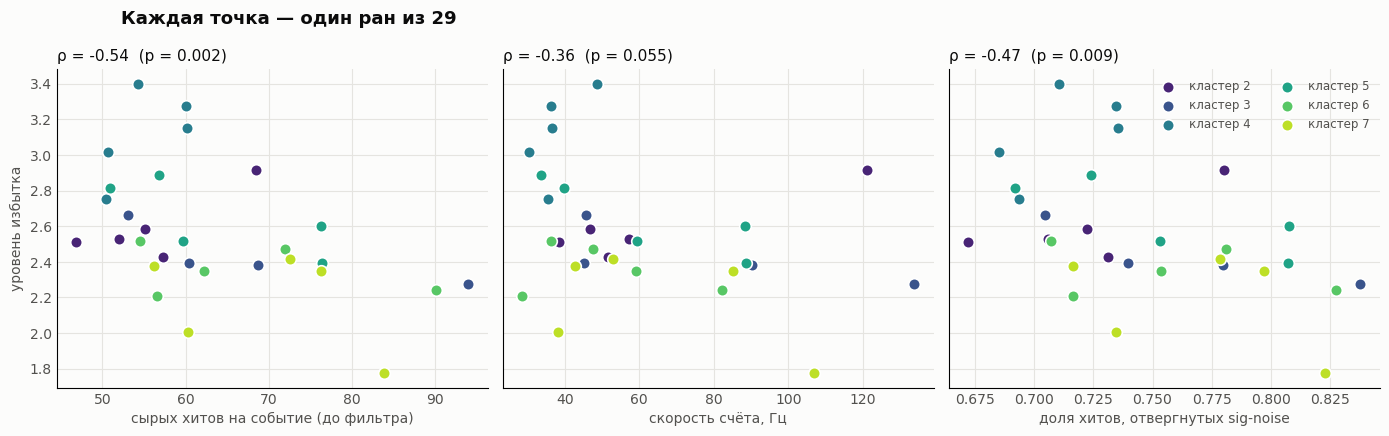

ρ — ранговая корреляция Спирмена: +1 = строгий рост, −1 = строгое падение,
0 = связи нет. p — вероятность увидеть такую связь при её отсутствии.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharey=True)
fig.patch.set_facecolor(SURFACE)
proxies = [("raw_hits_per_event", "сырых хитов на событие (до фильтра)"),
           ("trigger_rate_hz", "скорость счёта, Гц"),
           ("sn_reject_frac", "доля хитов, отвергнутых sig-noise")]
palette = plt.cm.viridis(np.linspace(0.1, 0.9, 6))
for ax, (column, label) in zip(axes, proxies):
    ax.set_facecolor(SURFACE); ax.grid(color="#e5e4e0", lw=0.8)
    ax.set_axisbelow(True); ax.tick_params(colors=MUTED, length=0)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for cluster, colour in zip(sorted(runs.cluster.unique()), palette):
        sub = runs[runs.cluster == cluster]
        ax.scatter(sub[column], np.exp(sub.level), s=70, color=colour,
                   edgecolor="white", lw=1.2, label=f"кластер {cluster}", zorder=3)
    rho, pval = stats.spearmanr(runs[column], runs.level)
    ax.set_xlabel(label, color=MUTED)
    ax.set_title(f"ρ = {rho:+.2f}  (p = {pval:.3f})", loc="left",
                 fontsize=11, color=INK)
axes[0].set_ylabel("уровень избытка", color=MUTED)
axes[2].legend(frameon=False, fontsize=8.5, labelcolor=MUTED, ncol=2)
fig.suptitle("Каждая точка — один ран из 29", x=0.09, ha="left",
             fontsize=13, fontweight="bold", color=INK)
plt.tight_layout()
plt.savefig(HERE / "figures" / "10_excess_vs_noise.png", dpi=150,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()
print("ρ — ранговая корреляция Спирмена: +1 = строгий рост, −1 = строгое падение,")
print("0 = связи нет. p — вероятность увидеть такую связь при её отсутствии.")

Знак **отрицательный** во всех трёх панелях: избыток слегка *падает* с шумовой
нагрузкой. Шумовая версия (b) предсказывала рост. То есть требуемого эффекта нет,
а имеющийся направлен в другую сторону.

Но цвета сразу выдают подвох: точки группируются по кластерам.

## Шаг 5. Два конфаунда, которые при 29 ранах не обойти

**Кластер.** Кластеры различаются и по шуму, и по избытку. Сырая корреляция не
может сказать, что из двух действует.

In [7]:
by_cluster = runs.groupby("cluster").agg(
    raw_hits_per_event=("raw_hits_per_event", "mean"),
    trigger_rate_hz=("trigger_rate_hz", "mean"),
    quality_frac=("quality_frac", "mean"),
    level=("level", "mean")).reset_index()
by_cluster["excess"] = np.exp(by_cluster.level)
present.show(
    by_cluster,
    {"cluster": "кластер", "raw_hits_per_event": "сырых хитов на событие",
     "trigger_rate_hz": "скорость счёта, Гц",
     "quality_frac": "доля прошедших отбор качества", "excess": "уровень избытка"},
    rows="один кластер, усреднение по его ранам",
    source=present.artefact_note(DATA / "10_run_noise.parquet"),
    note="Кластер 4 одновременно самый тихий и самый избыточный, кластер 7 — "
         "наоборот. Значит связь избытка с кластером не сводится к шуму.",
    decimals=3)

Строка — один кластер, усреднение по его ранам.
Кластер 4 одновременно самый тихий и самый избыточный, кластер 7 — наоборот. Значит связь
избытка с кластером не сводится к шуму.
Источник: стадия 10_run_noise, файл 10_run_noise.parquet, 29 строк


кластер,сырых хитов на событие,"скорость счёта, Гц",доля прошедших отбор качества,уровень избытка
2,55.943000,63.014000,0.025000,2.589000
3,69.024000,78.735000,0.024000,2.425000
4,55.069000,37.517000,0.047000,3.111000
5,64.023000,61.967000,0.025000,2.635000
6,67.064000,50.706000,0.035000,2.355000
7,69.841000,65.158000,0.030000,2.169000


**Знаменатель.** Доля событий, прошедших отбор качества, входит в знаменатель
избытка напрямую, поэтому всё, что её меняет, двигает избыток механически, безо
всякой физики.

Оба конфаунда снимаются ранговой регрессией: из прокси и из уровня вычитается то,
что предсказывается контрольной переменной, и корреляция считается по остаткам.

In [8]:
level = partial[partial.target == "level"]
wide = level.pivot(index="proxy", columns="control", values="rho")[
    ["none", "cluster", "quality_frac", "both"]].reset_index()
wide = present.rename_values(wide, "proxy")
present.show(
    wide,
    {"proxy": "чем меряем шум", "none": "сырая корреляция",
     "cluster": "с поправкой на кластер",
     "quality_frac": "с поправкой на знаменатель",
     "both": "с поправкой на оба"},
    rows="один способ померить шум",
    source=present.artefact_note(DATA / "10_run_noise_partial.parquet"),
    note="Все числа — ранговая корреляция уровня избытка с шумом. Шумовая версия "
         "(b) предсказывает ПОЛОЖИТЕЛЬНУЮ корреляцию. Ни в одном столбце её нет.",
    decimals=3)

print("\nНо контрольные переменные почти дублируют друг друга:")
corr = runs[["trigger_rate_hz", "quality_frac", "raw_hits_per_event",
             "sn_reject_frac"]].corr(method="spearman").reset_index()
corr = present.rename_values(corr, "index")
present.show(
    corr,
    {"index": "", "trigger_rate_hz": "скорость счёта",
     "quality_frac": "доля прошедших отбор",
     "raw_hits_per_event": "сырых хитов", "sn_reject_frac": "отвергнуто фильтром"},
    rows="взаимная корреляция переменных",
    source="та же таблица ранов",
    note="Скорость счёта и доля прошедших отбор связаны на −0.95. Поправка на "
         "вторую вычитает почти всю дисперсию первой — то есть последний столбец "
         "предыдущей таблицы мог обнулиться просто по построению.",
    decimals=2)

Строка — один способ померить шум.
Все числа — ранговая корреляция уровня избытка с шумом. Шумовая версия (b) предсказывает
ПОЛОЖИТЕЛЬНУЮ корреляцию. Ни в одном столбце её нет.
Источник: стадия 10_run_noise, файл 10_run_noise_partial.parquet, 24 строки


чем меряем шум,сырая корреляция,с поправкой на кластер,с поправкой на знаменатель,с поправкой на оба
сырых хитов на событие,-0.542000,-0.446000,-0.454000,-0.179000
"доля хитов, отвергнутых фильтром",-0.473000,-0.393000,-0.356000,-0.056000
"скорость счёта, Гц",-0.360000,-0.436000,-0.143000,-0.037000



Но контрольные переменные почти дублируют друг друга:
Строка — взаимная корреляция переменных.
Скорость счёта и доля прошедших отбор связаны на −0.95. Поправка на вторую вычитает почти всю
дисперсию первой — то есть последний столбец предыдущей таблицы мог обнулиться просто по
построению.
Источник: та же таблица ранов


,скорость счёта,доля прошедших отбор,сырых хитов,отвергнуто фильтром
"скорость счёта, Гц",1.000000,-0.950000,0.700000,0.750000
"доля событий, прошедших отбор",-0.950000,1.000000,-0.670000,-0.740000
сырых хитов на событие,0.700000,-0.670000,1.000000,0.980000
"доля хитов, отвергнутых фильтром",0.750000,-0.740000,0.980000,1.000000


## Что можно и чего нельзя заключить

**Можно.** Ни один способ померить шум не показывает роста избытка. Знак всюду
отрицательный — ни в сыром виде, ни после любой поправки предсказанного эффекта
нет. Наклон профиля (см. `31_by_band` и файл `10_run_noise_correlations.parquet`)
с шумом не связан вовсе: |ρ| ≤ 0.36 при p > 0.2. А ведь ошибка отклика должна была
бы менять именно наклон, ударяя по трудному хвосту сильнее.

**Нельзя.** Заявить измеренный ноль. После снятия обеих поправок корреляции
падают до −0.18, −0.06 и −0.04, но контрольные переменные коллинеарны на −0.95:
при 29 ранах эти оси не разделяются. Правильная формулировка — **схема не
обладает мощностью различить их**, а не «эффекта нет».

**Побочный результат, который стоит отдельного разбора.** Избыток систематически
зависит от кластера: 2.4 у седьмого против 3.1 у четвёртого. Это не шум — кластер
4 одновременно самый тихий и самый избыточный. Кластеры различаются геометрией,
числом рабочих модулей и калибровкой, а симуляция описывает одну конфигурацию.
Это указывает скорее на статическую ошибку описания детектора, чем на
динамическую шумовую, и относится уже к тесту 1 (`30_response.ipynb`).

**Что дальше.** Тест 2 (`20_flux_reweight.ipynb`) проверяет альтернативу (a):
может ли ошибка в потоке мюонов породить избыток.